In [1]:
import qutip as qt
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import cProfile, pstats, io
from pstats import SortKey

In [2]:
N = 3
a = qt.create(N)
lindbladian = qt.lindblad_dissipator(a.dag())
Id = qt.identity(N)
lindbladians = [qt.super_tensor(qt.to_super(Id),lindbladian),qt.super_tensor(lindbladian,qt.to_super(Id))]

In [3]:
def QFIMatrix(rho, lindbladians):
    (lambdas, Uw) = rho.eigenstates(output_type='oper')
    dims = rho.dims
    lambdas = np.round(lambdas,10)
    #lamfixed = np.where(lambdas>0,lambdas,0)
    U = qt.dimensions.from_tensor_rep(np.reshape(qt.dimensions.to_tensor_rep(Uw),np.array(dims).flatten()),dims)
    leffs = [U.dag() * qt.vector_to_operator(lindbladian*qt.operator_to_vector(rho))*U for lindbladian in lindbladians]
    [lambda1,lambda2] = np.meshgrid(lambdas,lambdas)

    # Vectorized logic to calculate the QFI
    # May be improved in the future, but works very well now
    matsize = [np.prod(dims[0]),np.prod(dims[1])]
    tops = [np.reshape(qt.dimensions.to_tensor_rep(leff),matsize) for leff in leffs]
    bot = (lambda1 + lambda2)
    FIs = [[ np.nansum(top1*top2/bot) for top1 in tops] for top2 in tops]
    return np.real_if_close(FIs)

In [4]:
def BMat(avals):
    size = np.size(avals)
    B = np.identity(size)
    ind = np.nonzero(avals)[0][0]
    mask = np.ones(size, dtype = bool)
    mask[ind] = 0
    B[0,ind] = 1
    B[ind,ind]=0
    B[ind,0] = 1/avals[ind]
    B[mask,0] = -avals[mask]/avals[ind]
    return B

In [5]:
def Calc_Qeff(rho0, annihilators, weights, transmisivities):
    # "Hot Path" for this function is primarily the matrix exponentiation
    # If we want to reuse stuff it might be simplest to exponentiate once
    # and then repeatedly multiply them
    
    # First calculate the state after the beamsplitters
    dims = rho0.dims
    ident = qt.identity(dims[0])
    vac = qt.basis(dims[0]).proj()
    thetas = np.arccos(np.sqrt(transmisivities))
    As = [qt.tensor(a,ident).dag()*qt.tensor(ident,a) + qt.tensor(a,ident)*qt.tensor(ident,a).dag() for a in annihilators]
    Gs = thetas *1j*As
    Us = np.sum(Gs).expm()
    rhoexpand = qt.tensor(rho0,vac)
    rhofexpand = Us * rhoexpand*Us.dag()
    rhof = rhofexpand.ptrace(np.arange(np.size(dims[0])))

    # Then create the Lindbladians
    lindbladians = [ qt.lindblad_dissipator(a) for a in annihilators]

    tans = np.sqrt((1-transmisivities)/transmisivities)

    # Create matricies
    QFI = QFIMatrix(rhof,lindbladians)
    D = np.diag(tans)
    B = BMat(weights)
    QFIT = B@D@QFI@D@np.transpose(B)
    Qeff = np.linalg.pinv(QFIT,hermitian=True)[0,0]
    return Qeff

In [6]:
rho0_1d = (qt.basis(N,2)+qt.basis(N)).unit().proj()
res_1d = qt.mesolve(lindbladian,rho0_1d,np.linspace(0,.1,1000),options={'store_final_state': True})

In [7]:
rho0 = qt.tensor(rho0_1d,rho0_1d)
res = qt.mesolve(lindbladians,rho0,np.linspace(0,.1,1000),options={'store_final_state': True})

In [8]:
Calc_Qeff(rho0, [qt.tensor(a.dag(),Id),qt.tensor(Id,a.dag())],np.array([1,1]),np.array([.1,.1]))

np.float64(4.439024392370293)

In [9]:
etas = np.linspace(0.01,0.99,7)
[eta1,eta2] = np.meshgrid(etas,etas)
#with cProfile.Profile() as pr:
Qs = np.array([[ Calc_Qeff(rho0, [qt.tensor(a.dag(),Id),qt.tensor(Id,a.dag())],np.array([1,1]),np.array([eta1[i,j],eta2[i,j]])) for i in range(7)] for j in range(7)])
#eps = pstats.Stats(pr).sort_stats("cumtime")  # cumulative time by function
#ps.print_stats(20)

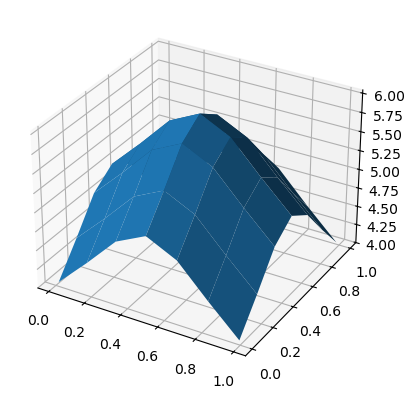

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(eta1,eta2,Qs)
plt.show()